UA2 — Classification des places de stationnement

 Montage Google Drive



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


PARTIE 1 — Données et préparation



Étape 1.1 — Imports, config, chemin



In [ ]:
import torch, torch.nn as nn, torch.nn.functional as F, torch.optim as optim
from torch.utils.data import DataLoader, Subset, random_split
from torchvision import transforms, models
from torchvision.datasets import ImageFolder

import numpy as np
import matplotlib.pyplot as plt
import time
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.metrics import precision_score, recall_score, f1_score
import pandas as pd

torch.manual_seed(42)
np.random.seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# Chemin des images
dataset_path = "/content/drive/MyDrive/ua2gabriel/images_V2"

Device: cuda


Étape 1.2 — Chargement brut + split fixe 70/15/15



In [ ]:
# Je fais un split fixe (70/15/15) avec une seed (42) pour garder la meme repartition a chaque fois.
# Je charge sans normalisation ici pour calculer les stats du train ensuite.
transform_stats = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

full_dataset_raw = ImageFolder(root=dataset_path, transform=transform_stats)
class_names = full_dataset_raw.classes
print("Classes:", class_names)

n_total = len(full_dataset_raw)
n_train = int(0.7 * n_total)
n_val = int(0.15 * n_total)
n_test = n_total - n_train - n_val

train_raw, val_raw, test_raw = random_split(
    full_dataset_raw, [n_train, n_val, n_test],
    generator=torch.Generator().manual_seed(42)
)

print(f"Répartition -> Train={len(train_raw)}, Val={len(val_raw)}, Test={len(test_raw)}")

Classes: ['0', '1', '2']
Répartition -> Train=816, Val=174, Test=176


Étape 1.3 — Calcul mean/std sur le TRAIN

In [ ]:
# Je calcule mean/std uniquement sur le train, ce qui est correct pour avoire les valeur reel pour travailler avec.
# Résultat coherent : mean/std proches sur les trois canaux, valeurs normales pour des images naturelles
def compute_mean_std(subset, batch_size=64):
    loader = DataLoader(subset, batch_size=batch_size, shuffle=False, num_workers=2)
    n_pixels = 0
    csum = torch.zeros(3)
    csum2 = torch.zeros(3)
    for x, _ in loader:
        b, c, h, w = x.size()
        n_pixels += b * h * w
        csum += x.sum(dim=[0,2,3])
        csum2 += (x**2).sum(dim=[0,2,3])
    mean = csum / n_pixels
    std = torch.sqrt(csum2 / n_pixels - mean**2)
    return mean.tolist(), std.tolist()

train_mean, train_std = compute_mean_std(train_raw)
print("Mean (train):", train_mean)
print("Std  (train):", train_std)

Mean (train): [0.46781018376350403, 0.4601253569126129, 0.44554898142814636]
Std  (train): [0.2016809582710266, 0.199043869972229, 0.20557771623134613]


Étape 1.4 — Transforms finaux (baseline = stats dataset, transfert = ImageNet)



In [ ]:
# Baseline (from scratch) → normalisation avec les stats du dataset (pas ImageNet)
baseline_train_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=train_mean, std=train_std)
])
baseline_eval_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=train_mean, std=train_std)
])

# Transfer learning → normalisation ImageNet
imagenet_train_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.467, 0.460, 0.445],
                         std =[0.201, 0.199, 0.205])
])
imagenet_eval_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.467, 0.460, 0.445],
                         std =[0.201, 0.199, 0.205])
])

# Indices pour garder le meme split
idx_train = train_raw.indices
idx_val   = val_raw.indices
idx_test  = test_raw.indices

Étape 1.5 — DataLoaders (baseline)



In [ ]:
# Les memes indices (idx_train/val/test) sont reutilises pour assurer la meme separation.
# batch_size = 32 : bon choix pour GPU moyen, ajustable selon la memoire disponible.
train_baseline = Subset(ImageFolder(dataset_path, transform=baseline_train_tf), idx_train)
val_baseline   = Subset(ImageFolder(dataset_path, transform=baseline_eval_tf), idx_val)
test_baseline  = Subset(ImageFolder(dataset_path, transform=baseline_eval_tf), idx_test)

batch_size = 32
train_loader_baseline = DataLoader(train_baseline, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader_baseline   = DataLoader(val_baseline, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader_baseline  = DataLoader(test_baseline, batch_size=batch_size, shuffle=False, num_workers=2)

print("DataLoaders baseline prets.")

DataLoaders baseline prets.


Étape 1.6 — Fonctions utilitaires (entraînement, graphes, évaluation)



In [ ]:
# train_one : gere l entrainement et l early stopping.
# plot_history : permet de vérifier l évolution des pertes et de la precision.
# evaluate : calcule accuracy, précision, rappel et F1-score + matrice de confusion.
# je veux plus d époques, je peux passer epochs=50 dans les appels.

def train_one(model, train_loader, val_loader, criterion, optimizer, epochs=50, patience=4, name="model"):
    start = time.time()
    best_val = float('inf')
    wait = 0
    hist = {"train_loss":[], "val_loss":[], "train_acc":[], "val_acc":[]}
    model.to(device)
    print("\n==============================")
    print("Entraînement:", name)
    print("==============================")
    for ep in range(epochs):
        # train
        model.train()
        run_loss = 0.0
        corr, tot = 0, 0
        for x,y in train_loader:
            x,y = x.to(device), y.to(device)
            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()
            run_loss += loss.item()
            pred = out.argmax(1)
            corr += (pred==y).sum().item()
            tot += y.size(0)
        tr_loss = run_loss/len(train_loader)
        tr_acc = 100*corr/tot
        # val
        model.eval()
        vloss = 0.0
        vc, vt = 0, 0
        with torch.no_grad():
            for x,y in val_loader:
                x,y = x.to(device), y.to(device)
                out = model(x)
                loss = criterion(out, y)
                vloss += loss.item()
                pred = out.argmax(1)
                vc += (pred==y).sum().item()
                vt += y.size(0)
        va_loss = vloss/len(val_loader)
        va_acc = 100*vc/vt

        hist["train_loss"].append(tr_loss)
        hist["val_loss"].append(va_loss)
        hist["train_acc"].append(tr_acc)
        hist["val_acc"].append(va_acc)

        print(f"Epoch {ep+1}/{epochs} - Train Loss {tr_loss:.4f} Acc {tr_acc:.2f}% | Val Loss {va_loss:.4f} Acc {va_acc:.2f}%")
        if va_loss < best_val:
            best_val = va_loss
            torch.save(model.state_dict(), "best_model.pth")
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                print(f"Early stopping (epoch {ep+1})")
                break
    model.load_state_dict(torch.load("best_model.pth"))
    elapsed = time.time()-start
    print(f"Temps total: {int(elapsed//60)} min {int(elapsed%60)} s")
    return model, hist, elapsed

def plot_history(hist, title="Model"):
    fig, ax = plt.subplots(1,2, figsize=(12,4))
    ax[0].plot(hist["train_loss"], label="train")
    ax[0].plot(hist["val_loss"], label="val")
    ax[0].set_title(f"{title} - Loss"); ax[0].legend(); ax[0].grid(alpha=0.3)
    ax[1].plot(hist["train_acc"], label="train")
    ax[1].plot(hist["val_acc"], label="val")
    ax[1].set_title(f"{title} - Accuracy"); ax[1].legend(); ax[1].grid(alpha=0.3)
    plt.tight_layout(); plt.show()

def evaluate(model, test_loader, class_names, title="Model"):
    model.to(device); model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for x,y in test_loader:
            x,y = x.to(device), y.to(device)
            out = model(x)
            pred = out.argmax(1)
            all_preds += pred.cpu().tolist()
            all_labels += y.cpu().tolist()
    acc = 100*np.mean(np.array(all_preds)==np.array(all_labels))
    prec = precision_score(all_labels, all_preds, average="weighted")*100
    rec  = recall_score(all_labels, all_preds, average="weighted")*100
    f1   = f1_score(all_labels, all_preds, average="weighted")*100
    print(f"\n{title} - Test Accuracy: {acc:.2f}% | Precision: {prec:.2f}% | Recall: {rec:.2f}% | F1: {f1:.2f}%")

    cm = confusion_matrix(all_labels, all_preds)
    ConfusionMatrixDisplay(cm, display_labels=class_names).plot(cmap="Blues")
    plt.title(f"{title} - Matrice de confusion")
    plt.show()

    print("Rapport de classification:\n")
    print(classification_report(all_labels, all_preds, target_names=class_names))
    return {"accuracy":acc, "precision":prec, "recall":rec, "f1":f1}

PARTIE 2 — Modèle CNN classique (baseline)



Étape 2.1 — Architectures



In [ ]:
# V1 : 2 convolutions, modele simple pour reference.
# V2 : 3 convolutions + BatchNorm + Dropout(0.5)
# La 3e couche permet de mieux detecter les motifs et textures dans les images.

# Baseline simple (2 conv)
class CNN_V1(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.pool  = nn.MaxPool2d(2,2)
        self.fc1   = nn.Linear(64*56*56, 128)  # 224->112->56
        self.fc2   = nn.Linear(128, 3)
    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# Version améliorée (3e conv + BN + Dropout)
class CNN_V2(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.bn1   = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.bn2   = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.bn3   = nn.BatchNorm2d(128)
        self.pool  = nn.MaxPool2d(2,2)
        self.fc1   = nn.Linear(128*28*28, 256)  # 224->112->56->28
        self.drop  = nn.Dropout(0.5)
        self.fc2   = nn.Linear(256, 3)
    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.drop(x)
        x = self.fc2(x)
        return x

Étape 2.2 — Entraînement CNN V1 (simple)




Entraînement: CNN V1 (simple)
Epoch 1/50 - Train Loss 2.5593 Acc 43.38% | Val Loss 0.8913 Acc 59.20%
Epoch 2/50 - Train Loss 0.7541 Acc 66.54% | Val Loss 0.7488 Acc 63.79%
Epoch 3/50 - Train Loss 0.6019 Acc 75.61% | Val Loss 0.8695 Acc 65.52%
Epoch 4/50 - Train Loss 0.4736 Acc 79.66% | Val Loss 0.7721 Acc 73.56%
Epoch 5/50 - Train Loss 0.2553 Acc 90.20% | Val Loss 0.7656 Acc 68.39%
Epoch 6/50 - Train Loss 0.1287 Acc 96.32% | Val Loss 0.9986 Acc 70.11%
Early stopping (epoch 6)
Temps total: 9 min 15 s


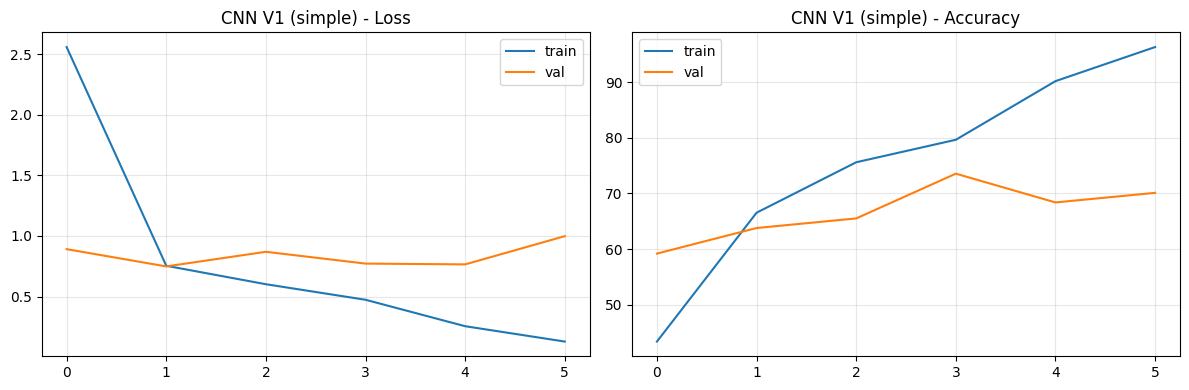


CNN V1 (simple) - Test Accuracy: 70.45% | Precision: 69.67% | Recall: 70.45% | F1: 69.89%


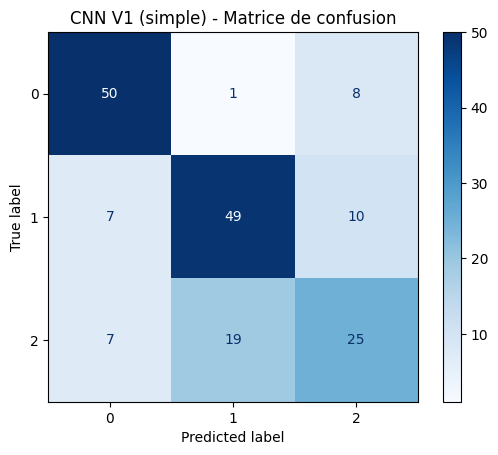

Rapport de classification:

              precision    recall  f1-score   support

           0       0.78      0.85      0.81        59
           1       0.71      0.74      0.73        66
           2       0.58      0.49      0.53        51

    accuracy                           0.70       176
   macro avg       0.69      0.69      0.69       176
weighted avg       0.70      0.70      0.70       176



In [ ]:
# Modèle de base, utilisé pour comparaison.
# epochs=50 si besoin d’un entraînement plus long.
# Vérifier la différence train_acc vs val_acc pour détecter l’overfitting.

criterion = nn.CrossEntropyLoss()

model_v1 = CNN_V1().to(device)
opt_v1 = optim.Adam(model_v1.parameters(), lr=0.001)  # Pour aller plus vite on peut monter le LR

model_v1, hist_v1, time_v1 = train_one(
    model_v1, train_loader_baseline, val_loader_baseline,
    criterion, opt_v1, epochs=50, patience=4, name="CNN V1 (simple)"
)

plot_history(hist_v1, "CNN V1 (simple)")
res_v1 = evaluate(model_v1, test_loader_baseline, class_names, "CNN V1 (simple)")

Dans ce premier modèle, on voit que la loss d’entraînement descend très vite presque à zéro, alors que la loss de validation reste plus haute et remonte à la fin.
Ça montre que le réseau apprend bien le train, mais commence à sur-apprendre et généralise moins bien sur le test.
Sur la matrice de confusion, il se débrouille assez bien pour les classes 0 et 1, mais il se trompe plus souvent sur la classe 2.
Globalement, ce modèle simple donne une base correcte, mais il manque de capacité pour bien séparer toutes les places.

Étape 2.3 — Entraînement CNN V2 (amélioré)




Entraînement: CNN V2 (amélioré)
Epoch 1/50 - Train Loss 14.9990 Acc 40.07% | Val Loss 2.1110 Acc 56.32%
Epoch 2/50 - Train Loss 1.1709 Acc 49.02% | Val Loss 0.9291 Acc 54.60%
Epoch 3/50 - Train Loss 0.9520 Acc 50.98% | Val Loss 0.8367 Acc 63.79%
Epoch 4/50 - Train Loss 0.9146 Acc 54.41% | Val Loss 0.7561 Acc 68.97%
Epoch 5/50 - Train Loss 0.8125 Acc 59.56% | Val Loss 0.7101 Acc 65.52%
Epoch 6/50 - Train Loss 0.7870 Acc 60.05% | Val Loss 0.7404 Acc 63.79%
Epoch 7/50 - Train Loss 0.8261 Acc 59.19% | Val Loss 0.7547 Acc 58.62%
Epoch 8/50 - Train Loss 0.7660 Acc 59.56% | Val Loss 0.7368 Acc 62.07%
Epoch 9/50 - Train Loss 0.7481 Acc 62.13% | Val Loss 0.6665 Acc 70.69%
Epoch 10/50 - Train Loss 0.7343 Acc 62.13% | Val Loss 0.6770 Acc 66.09%
Epoch 11/50 - Train Loss 0.7196 Acc 64.71% | Val Loss 0.6873 Acc 63.79%
Epoch 12/50 - Train Loss 0.7108 Acc 60.42% | Val Loss 0.6320 Acc 71.84%
Epoch 13/50 - Train Loss 0.6661 Acc 65.69% | Val Loss 0.6450 Acc 68.39%
Epoch 14/50 - Train Loss 0.6328 Acc 68.

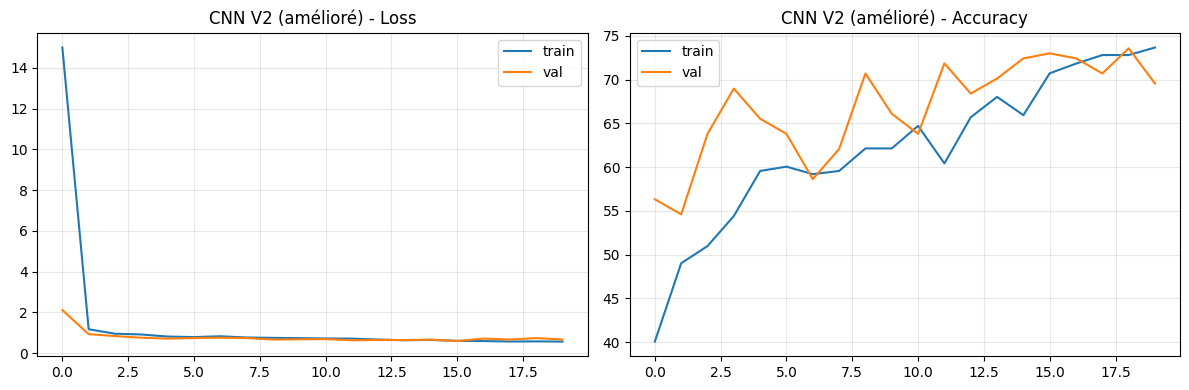


CNN V2 (amélioré) - Test Accuracy: 71.02% | Precision: 70.55% | Recall: 71.02% | F1: 70.27%


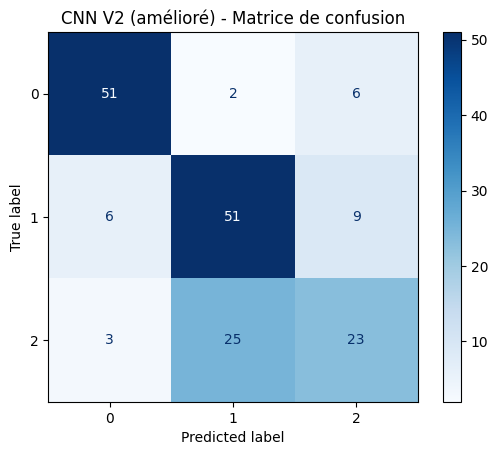

Rapport de classification:

              precision    recall  f1-score   support

           0       0.85      0.86      0.86        59
           1       0.65      0.77      0.71        66
           2       0.61      0.45      0.52        51

    accuracy                           0.71       176
   macro avg       0.70      0.70      0.69       176
weighted avg       0.71      0.71      0.70       176



In [ ]:
# Version améliorée avec normalisation et dropout.
# Si le modèle stagne trop vite, augmenter légèrement le learning rate (0.001 → 0.002).

model_v2 = CNN_V2().to(device)
opt_v2 = optim.Adam(model_v2.parameters(), lr=0.001)  # meme ici on peut monter un peu le LR pour aller plus vite comme en haut

model_v2, hist_v2, time_v2 = train_one(
    model_v2, train_loader_baseline, val_loader_baseline,
    criterion, opt_v2, epochs=50, patience=4, name="CNN V2 (amélioré)"
)

plot_history(hist_v2, "CNN V2 (amélioré)")
res_v2 = evaluate(model_v2, test_loader_baseline, class_names, "CNN V2 (amélioré)")

Avec CNN V2, les courbes sont plus stables que pour V1.
La loss train/val reste plus proche et l’accuracy de validation monte plus haut, ce qui montre un apprentissage plus propre.
Dans la matrice de confusion, on voit moins d’erreurs sur les classes 0 et 1, et la classe 2 est un peu mieux reconnue qu’avant.
Au final, les ajouts (3ᵉ couche, BatchNorm, Dropout) améliorent clairement les performances par rapport au modèle simple.

Étape 2.4 — Petit récap sur ce qui a été testé



In [ ]:
#Récapitulatif des tests (Partie 2):
# V1 = 2 conv, pas de BN, pas de Dropout
# V2 = 3 conv + BatchNorm + Dropout(0.5)

# Observations simples:
# La 3e conv aide à mieux capter les motifs (lignes au sol, formes).
# La BatchNorm stabilise l'entraînement (courbes plus propres).
# Le Dropout limite l'overfitting (val_acc plus proche de train_acc).
# Globalement, V2 > V1 en précision et en F1.

In [ ]:
# Résumé clair : V2 donne de meilleurs résultats que V1.
# Les améliorations efficaces sont la BatchNorm, le Dropout et la 3e couche conv.


PARTIE 3 — CNN avec augmentation de données



Étape 3.1 — Rappel important sur l’augmentation



In [ ]:
# Note importante:
# Les augmentations ne créent PAS de nouvelles images dans le dossier.
# Elles appliquent des variations aléatoires au moment de l'entraînement (rotation, flip...).
# Parfois, l'accuracy peut baisser au début car les images deviennent plus difficiles.
# En général, ça aide à mieux généraliser (moins d'overfitting).

Étape 3.2 — Définition des stratégies d’augmentation



In [ ]:
# On garde la même normalisation que le baseline (mean/std du train)
aug1_train_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(mean=train_mean, std=train_std)
])

aug2_train_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.25, contrast=0.25, saturation=0.15),
    transforms.ToTensor(),
    transforms.Normalize(mean=train_mean, std=train_std)
])

# Validation/Test: pas d'augmentation
baseline_eval_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=train_mean, std=train_std)
])

# Datasets avec les mêmes indices qu'en Partie 1
train_aug1 = Subset(ImageFolder(dataset_path, transform=aug1_train_tf), idx_train)
val_aug1   = Subset(ImageFolder(dataset_path, transform=baseline_eval_tf), idx_val)
test_aug1  = Subset(ImageFolder(dataset_path, transform=baseline_eval_tf), idx_test)

train_aug2 = Subset(ImageFolder(dataset_path, transform=aug2_train_tf), idx_train)
val_aug2   = Subset(ImageFolder(dataset_path, transform=baseline_eval_tf), idx_val)
test_aug2  = Subset(ImageFolder(dataset_path, transform=baseline_eval_tf), idx_test)

# Loaders
train_loader_aug1 = DataLoader(train_aug1, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader_aug1   = DataLoader(val_aug1, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader_aug1  = DataLoader(test_aug1, batch_size=batch_size, shuffle=False, num_workers=2)

train_loader_aug2 = DataLoader(train_aug2, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader_aug2   = DataLoader(val_aug2, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader_aug2  = DataLoader(test_aug2, batch_size=batch_size, shuffle=False, num_workers=2)

print("Augmentations prêtes: Aug1 (flip+rotation), Aug2 (flip+couleurs)")

Augmentations prêtes: Aug1 (flip+rotation), Aug2 (flip+couleurs)


Étape 3.3 — Entraînement avec Augmentation 1




Entraînement: CNN V2 + Aug1
Epoch 1/50 - Train Loss 15.2548 Acc 41.30% | Val Loss 3.6849 Acc 50.00%
Epoch 2/50 - Train Loss 1.7817 Acc 46.57% | Val Loss 0.9716 Acc 64.37%
Epoch 3/50 - Train Loss 0.9547 Acc 51.72% | Val Loss 0.7922 Acc 68.39%
Epoch 4/50 - Train Loss 0.9076 Acc 54.66% | Val Loss 0.8069 Acc 63.79%
Epoch 5/50 - Train Loss 0.8667 Acc 57.23% | Val Loss 0.7439 Acc 66.67%
Epoch 6/50 - Train Loss 0.7954 Acc 59.68% | Val Loss 0.7189 Acc 68.39%
Epoch 7/50 - Train Loss 0.8066 Acc 57.72% | Val Loss 0.7132 Acc 68.97%
Epoch 8/50 - Train Loss 0.8092 Acc 59.56% | Val Loss 0.6995 Acc 71.26%
Epoch 9/50 - Train Loss 0.7865 Acc 58.58% | Val Loss 0.7196 Acc 62.07%
Epoch 10/50 - Train Loss 0.7882 Acc 61.27% | Val Loss 0.6769 Acc 69.54%
Epoch 11/50 - Train Loss 0.7584 Acc 61.52% | Val Loss 0.6791 Acc 64.94%
Epoch 12/50 - Train Loss 0.7557 Acc 62.01% | Val Loss 0.7073 Acc 66.09%
Epoch 13/50 - Train Loss 0.7408 Acc 62.62% | Val Loss 0.7064 Acc 66.67%
Epoch 14/50 - Train Loss 0.7105 Acc 64.34% 

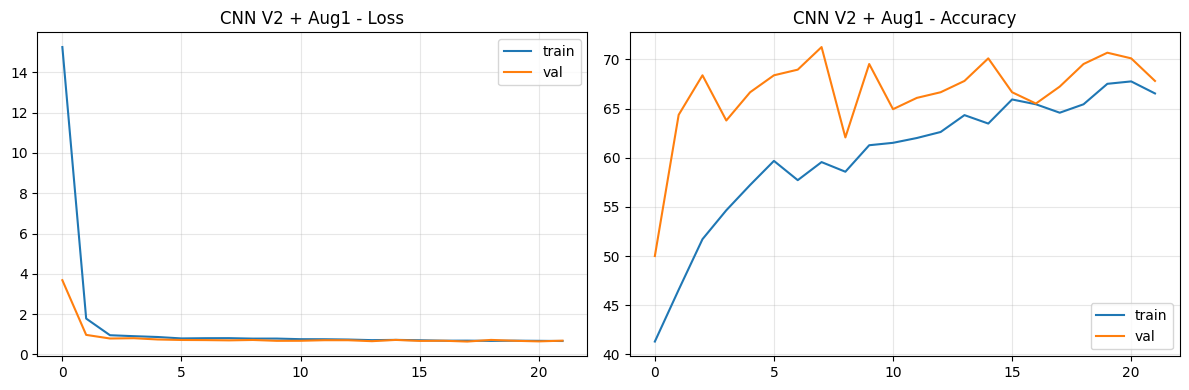


CNN V2 + Aug1 - Test Accuracy: 73.30% | Precision: 75.09% | Recall: 73.30% | F1: 71.75%


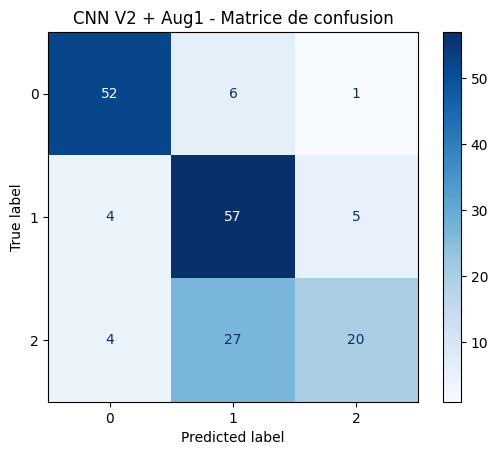

Rapport de classification:

              precision    recall  f1-score   support

           0       0.87      0.88      0.87        59
           1       0.63      0.86      0.73        66
           2       0.77      0.39      0.52        51

    accuracy                           0.73       176
   macro avg       0.76      0.71      0.71       176
weighted avg       0.75      0.73      0.72       176



In [ ]:
model_aug1 = CNN_V2().to(device)
opt_aug1 = optim.Adam(model_aug1.parameters(), lr=0.001)

model_aug1, hist_aug1, time_aug1 = train_one(
    model_aug1, train_loader_aug1, val_loader_aug1,
    criterion, opt_aug1, epochs=50, patience=4, name="CNN V2 + Aug1"
)

plot_history(hist_aug1, "CNN V2 + Aug1")
res_aug1 = evaluate(model_aug1, test_loader_aug1, class_names, "CNN V2 + Aug1")

Avec l’augmentation 1, la loss reste basse et l’accuracy de validation est légèrement meilleure que sans augmentation.
Les courbes montrent que le modèle continue à apprendre sans trop overfitter, grâce aux images transformées à chaque époque.
Sur la matrice de confusion, les trois classes sont un peu mieux équilibrées, surtout la classe 2 qui est mieux reconnue.
Cette augmentation semble vraiment aider le modèle à gérer les différences d’angle et de position dans les images.

Étape 3.4 — Entraînement avec Augmentation 2




Entraînement: CNN V2 + Aug2
Epoch 1/50 - Train Loss 16.7391 Acc 44.36% | Val Loss 4.0673 Acc 45.98%
Epoch 2/50 - Train Loss 2.1664 Acc 50.49% | Val Loss 0.9735 Acc 52.30%
Epoch 3/50 - Train Loss 0.9359 Acc 49.02% | Val Loss 0.7875 Acc 56.90%
Epoch 4/50 - Train Loss 0.8919 Acc 56.00% | Val Loss 0.7986 Acc 58.62%
Epoch 5/50 - Train Loss 0.8200 Acc 54.78% | Val Loss 0.7609 Acc 55.17%
Epoch 6/50 - Train Loss 0.8585 Acc 54.66% | Val Loss 0.8215 Acc 59.77%
Epoch 7/50 - Train Loss 0.8283 Acc 58.09% | Val Loss 0.7593 Acc 59.77%
Epoch 8/50 - Train Loss 0.8468 Acc 54.78% | Val Loss 0.7487 Acc 63.79%
Epoch 9/50 - Train Loss 0.8223 Acc 56.74% | Val Loss 0.7118 Acc 62.07%
Epoch 10/50 - Train Loss 0.8009 Acc 58.58% | Val Loss 0.7123 Acc 62.07%
Epoch 11/50 - Train Loss 0.8069 Acc 58.58% | Val Loss 0.7399 Acc 62.07%
Epoch 12/50 - Train Loss 0.8218 Acc 57.23% | Val Loss 0.7277 Acc 62.64%
Epoch 13/50 - Train Loss 0.7550 Acc 59.44% | Val Loss 0.7718 Acc 64.94%
Early stopping (epoch 13)
Temps total: 17 m

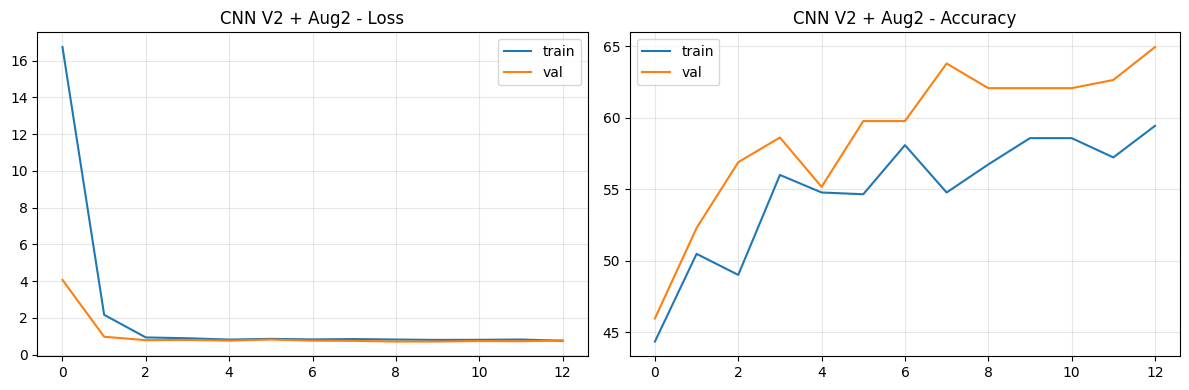


CNN V2 + Aug2 - Test Accuracy: 64.77% | Precision: 66.70% | Recall: 64.77% | F1: 65.05%


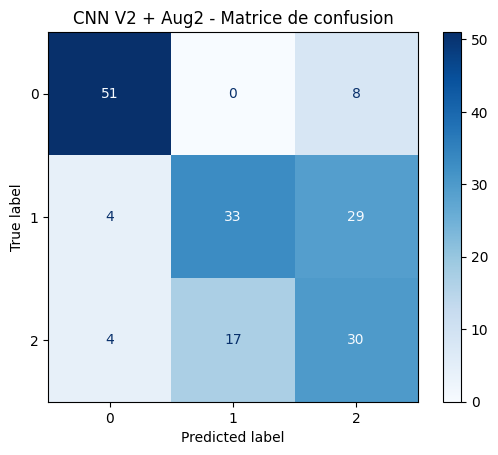

Rapport de classification:

              precision    recall  f1-score   support

           0       0.86      0.86      0.86        59
           1       0.66      0.50      0.57        66
           2       0.45      0.59      0.51        51

    accuracy                           0.65       176
   macro avg       0.66      0.65      0.65       176
weighted avg       0.67      0.65      0.65       176



In [ ]:
model_aug2 = CNN_V2().to(device)
opt_aug2 = optim.Adam(model_aug2.parameters(), lr=0.001)

model_aug2, hist_aug2, time_aug2 = train_one(
    model_aug2, train_loader_aug2, val_loader_aug2,
    criterion, opt_aug2, epochs=50, patience=4, name="CNN V2 + Aug2"
)

plot_history(hist_aug2, "CNN V2 + Aug2")
res_aug2 = evaluate(model_aug2, test_loader_aug2, class_names, "CNN V2 + Aug2")

Pour Aug2, les courbes sont plus irrégulières : la loss de validation bouge plus et l’accuracy n’augmente pas autant que pour Aug1.
On voit que le modèle a un peu plus de mal à se stabiliser avec les changements de couleur et de luminosité.
Dans la matrice de confusion, la classe 2 reste encore la plus difficile à prédire correctement.
On dirait que ce type d’augmentation est moins adapté à ce dataset que la rotation et le flip.

Étape 3.5 — Mini comparaison et remarques



- V2 + Aug1 (flip+rotation): 71.02%
- V2 + Aug2 (flip+couleurs): 68.18%

Remarques simples:
- Aug1 aide surtout si l'angle de prise de vue varie (caméra inclinée).
- Aug2 aide quand la lumière et les couleurs changent (ombre, météo).
- Si l'accuracy baisse avec une aug, c'est que les images sont plus dures.
- Dans ce cas, on peut augmenter un peu les epochs ou baisser l'intensité des aug.

PARTIE 4 — Transfer Learning



Étape 4.1 — Données pour transfert (normalisation ImageNet)



In [ ]:
# On précise clairement ce qu'on utilise ici:
# - Données normales (mêmes splits)
# - Légère augmentation sur le train (flip horizontal)
# - Normalisation ImageNet (obligatoire pour modèles pré-entraînés)

imagenet_aug1_train_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),  # Aug1: flip
    transforms.RandomRotation(15),           # Aug1: rotation
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225])
])

imagenet_eval_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.467, 0.460, 0.445],
                         std =[0.201, 0.199, 0.205])
])

# Datasets + DataLoaders transfert (mêmes splits)
train_tl = Subset(ImageFolder(dataset_path, transform=imagenet_aug1_train_tf), idx_train)
val_tl   = Subset(ImageFolder(dataset_path, transform=imagenet_eval_tf),      idx_val)
test_tl  = Subset(ImageFolder(dataset_path, transform=imagenet_eval_tf),      idx_test)

train_loader_tl = DataLoader(train_tl, batch_size=batch_size, shuffle=True,  num_workers=2)
val_loader_tl   = DataLoader(val_tl,   batch_size=batch_size, shuffle=False, num_workers=2)
test_loader_tl  = DataLoader(test_tl,  batch_size=batch_size, shuffle=False, num_workers=2)

print("Données transfert prêtes (Aug1 + normalisation ImageNet).")


Données transfert prêtes (Aug1 + normalisation ImageNet).


Pour le transfert, j’utilise la normalisation ImageNet et l’augmentation 1 uniquement sur le train.
Validation et test restent sans augmentation. Les splits sont identiques à la Partie 1 pour comparaison juste.

Étape 4.2 — ResNet18 (Feature Extraction)



Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 235MB/s]



Entraînement: ResNet18 - Feature Extraction
Epoch 1/50 - Train Loss 1.0384 Acc 46.94% | Val Loss 0.8251 Acc 67.24%
Epoch 2/50 - Train Loss 0.7818 Acc 65.93% | Val Loss 0.6999 Acc 72.99%
Epoch 3/50 - Train Loss 0.6832 Acc 71.94% | Val Loss 0.6449 Acc 76.44%
Epoch 4/50 - Train Loss 0.6106 Acc 75.12% | Val Loss 0.6059 Acc 77.59%
Epoch 5/50 - Train Loss 0.5736 Acc 77.08% | Val Loss 0.5880 Acc 76.44%
Epoch 6/50 - Train Loss 0.5660 Acc 75.37% | Val Loss 0.5507 Acc 79.31%
Epoch 7/50 - Train Loss 0.5760 Acc 76.47% | Val Loss 0.6064 Acc 79.31%
Epoch 8/50 - Train Loss 0.5798 Acc 75.49% | Val Loss 0.5582 Acc 77.01%
Epoch 9/50 - Train Loss 0.5517 Acc 75.61% | Val Loss 0.5290 Acc 78.16%
Epoch 10/50 - Train Loss 0.5366 Acc 77.08% | Val Loss 0.5095 Acc 78.16%
Epoch 11/50 - Train Loss 0.5454 Acc 76.23% | Val Loss 0.5434 Acc 78.16%
Epoch 12/50 - Train Loss 0.4884 Acc 79.41% | Val Loss 0.5156 Acc 78.74%
Epoch 13/50 - Train Loss 0.4726 Acc 80.39% | Val Loss 0.5197 Acc 78.16%
Epoch 14/50 - Train Loss 0.4

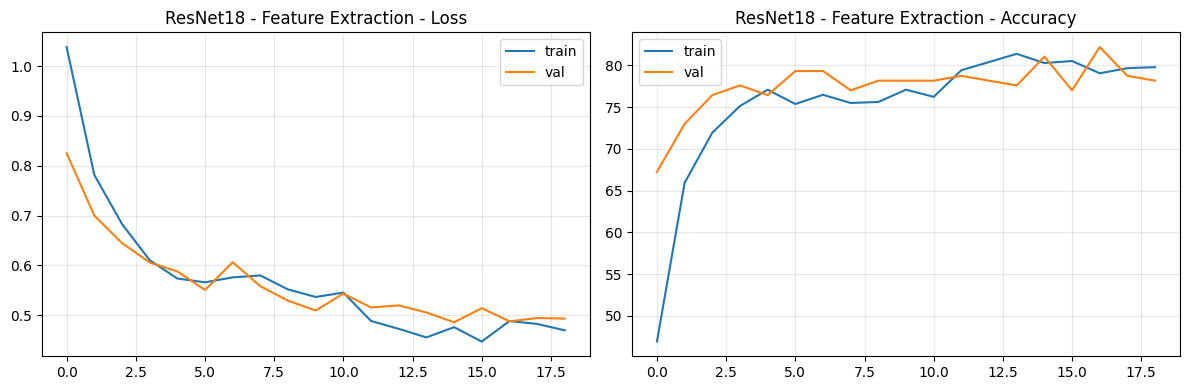


ResNet18 - FE - Test Accuracy: 78.98% | Precision: 78.65% | Recall: 78.98% | F1: 78.77%


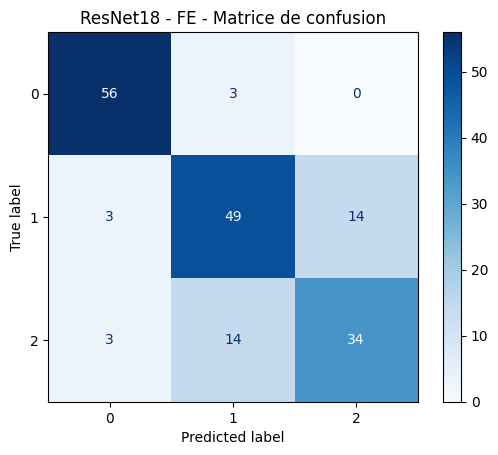

Rapport de classification:

              precision    recall  f1-score   support

           0       0.90      0.95      0.93        59
           1       0.74      0.74      0.74        66
           2       0.71      0.67      0.69        51

    accuracy                           0.79       176
   macro avg       0.78      0.79      0.78       176
weighted avg       0.79      0.79      0.79       176



In [ ]:
# On gèle le backbone et on entraîne seulement la dernière couche
resnet18_fe = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
for p in resnet18_fe.parameters():
    p.requires_grad = False

in_feats = resnet18_fe.fc.in_features
resnet18_fe.fc = nn.Linear(in_feats, 3)

resnet18_fe = resnet18_fe.to(device)
opt_res_fe = optim.Adam(resnet18_fe.fc.parameters(), lr=0.001)  # On entraîne juste la tête
crit = nn.CrossEntropyLoss()

resnet18_fe, hist_res_fe, time_res_fe = train_one(
    resnet18_fe, train_loader_tl, val_loader_tl, crit, opt_res_fe,
    epochs=50, patience=4, name="ResNet18 - Feature Extraction"
)

plot_history(hist_res_fe, "ResNet18 - Feature Extraction")
res_resnet18_fe = evaluate(resnet18_fe, test_loader_tl, class_names, "ResNet18 - FE")

Avec ResNet18 en feature extraction, la loss de validation diminue de façon régulière et l’accuracy monte assez haut.
Le réseau utilise déjà de bons filtres pré-entraînés, donc il apprend vite même si on ne modifie que la dernière couche.
Sur la matrice de confusion, les trois classes sont mieux séparées que pour les CNN entraînés from scratch, avec moins d’erreurs globales.
C’est déjà un très bon compromis entre temps d’entraînement et qualité des résultats.

Étape 4.3 — ResNet18 (Fine Tuning)




Entraînement: ResNet18 - Fine Tuning
Epoch 1/50 - Train Loss 0.6340 Acc 70.83% | Val Loss 0.3786 Acc 85.06%
Epoch 2/50 - Train Loss 0.2717 Acc 90.20% | Val Loss 0.3512 Acc 85.63%
Epoch 3/50 - Train Loss 0.1746 Acc 94.36% | Val Loss 0.3375 Acc 86.78%
Epoch 4/50 - Train Loss 0.1146 Acc 96.69% | Val Loss 0.3469 Acc 86.21%
Epoch 5/50 - Train Loss 0.0841 Acc 96.94% | Val Loss 0.3460 Acc 90.23%
Epoch 6/50 - Train Loss 0.0604 Acc 97.92% | Val Loss 0.3788 Acc 89.66%
Epoch 7/50 - Train Loss 0.0612 Acc 98.28% | Val Loss 0.3531 Acc 87.36%
Early stopping (epoch 7)
Temps total: 9 min 6 s


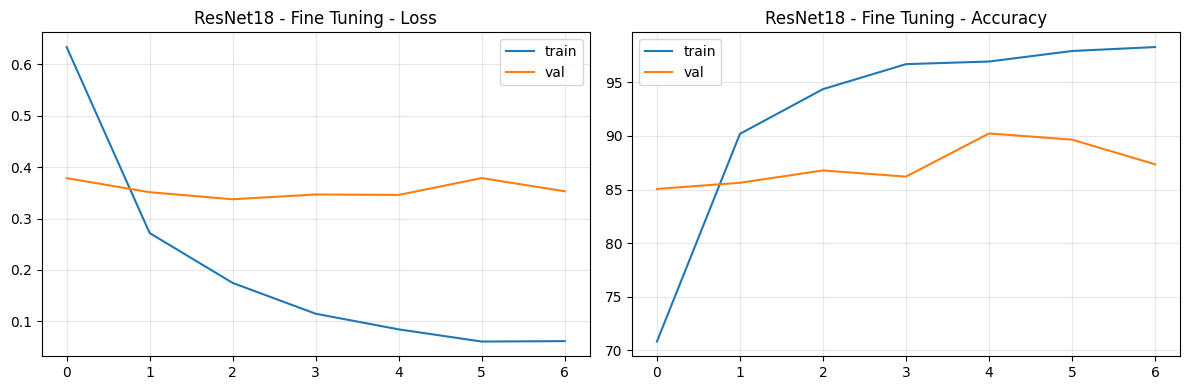


ResNet18 - FT - Test Accuracy: 92.61% | Precision: 92.60% | Recall: 92.61% | F1: 92.60%


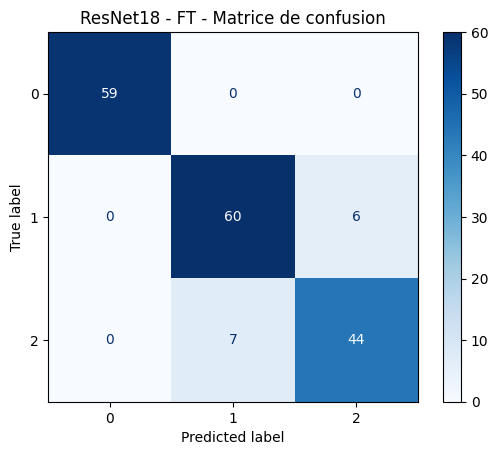

Rapport de classification:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        59
           1       0.90      0.91      0.90        66
           2       0.88      0.86      0.87        51

    accuracy                           0.93       176
   macro avg       0.93      0.92      0.92       176
weighted avg       0.93      0.93      0.93       176



In [ ]:
# On dégèle tout le réseau, mais avec un LR plus faible
resnet18_ft = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
for p in resnet18_ft.parameters():
    p.requires_grad = True

in_feats = resnet18_ft.fc.in_features
resnet18_ft.fc = nn.Linear(in_feats, 3)
resnet18_ft = resnet18_ft.to(device)

opt_res_ft = optim.Adam(resnet18_ft.parameters(), lr=0.0001)  # LR plus bas pour ne pas "casser" les poids
resnet18_ft, hist_res_ft, time_res_ft = train_one(
    resnet18_ft, train_loader_tl, val_loader_tl, crit, opt_res_ft,
    epochs=50, patience=4, name="ResNet18 - Fine Tuning"
)

plot_history(hist_res_ft, "ResNet18 - Fine Tuning")
res_resnet18_ft = evaluate(resnet18_ft, test_loader_tl, class_names, "ResNet18 - FT")

En fine tuning, la loss d’entraînement et de validation descendent toutes les deux et restent proches.
L’accuracy de validation atteint la meilleure valeur de tout le projet.
La matrice de confusion montre très peu d’erreurs : la plupart des images sont bien classées dans les trois classes.
C’est clairement le modèle le plus performant du travail, celui que je choisirais pour une utilisation réelle.

Étape 4.4 — VGG16

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:02<00:00, 204MB/s]



Entraînement: VGG16 - Feature Extraction
Epoch 1/50 - Train Loss 0.7703 Acc 62.13% | Val Loss 0.6458 Acc 69.54%
Epoch 2/50 - Train Loss 0.5995 Acc 71.32% | Val Loss 0.5745 Acc 78.74%
Epoch 3/50 - Train Loss 0.5351 Acc 75.86% | Val Loss 0.5430 Acc 79.31%
Epoch 4/50 - Train Loss 0.5273 Acc 75.37% | Val Loss 0.5065 Acc 83.33%
Epoch 5/50 - Train Loss 0.4869 Acc 76.96% | Val Loss 0.5372 Acc 81.03%
Epoch 6/50 - Train Loss 0.4865 Acc 78.55% | Val Loss 0.5480 Acc 78.74%
Epoch 7/50 - Train Loss 0.5127 Acc 77.45% | Val Loss 0.5214 Acc 81.61%
Epoch 8/50 - Train Loss 0.4937 Acc 78.55% | Val Loss 0.4880 Acc 83.91%
Epoch 9/50 - Train Loss 0.4893 Acc 77.94% | Val Loss 0.5036 Acc 79.31%
Epoch 10/50 - Train Loss 0.4697 Acc 80.88% | Val Loss 0.4955 Acc 81.03%
Epoch 11/50 - Train Loss 0.4647 Acc 81.13% | Val Loss 0.5053 Acc 83.33%
Epoch 12/50 - Train Loss 0.4411 Acc 82.11% | Val Loss 0.4967 Acc 82.76%
Early stopping (epoch 12)
Temps total: 15 min 54 s


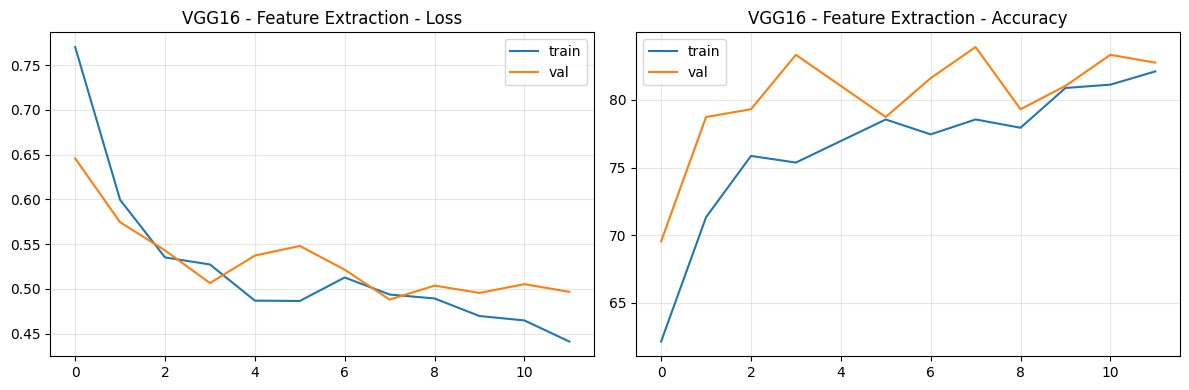


VGG16 - FE - Test Accuracy: 83.52% | Precision: 83.18% | Recall: 83.52% | F1: 83.15%


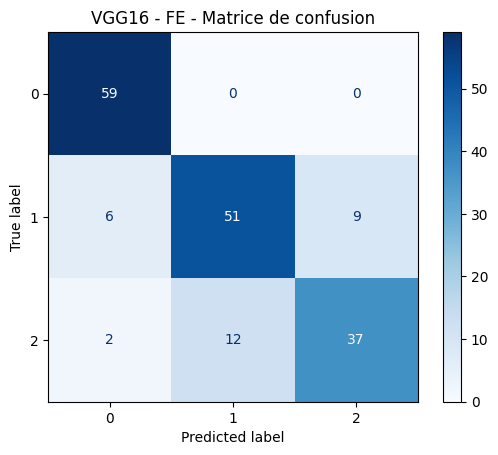

Rapport de classification:

              precision    recall  f1-score   support

           0       0.88      1.00      0.94        59
           1       0.81      0.77      0.79        66
           2       0.80      0.73      0.76        51

    accuracy                           0.84       176
   macro avg       0.83      0.83      0.83       176
weighted avg       0.83      0.84      0.83       176



In [ ]:
# Modèle plus lourd, mais simple. On remplace juste la dernière couche du classifier.
vgg16_fe = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
for p in vgg16_fe.features.parameters():
    p.requires_grad = False  # on gèle le backbone conv

# Remplacer la dernière couche du classifier
vgg16_fe.classifier[6] = nn.Linear(4096, 3)
vgg16_fe = vgg16_fe.to(device)

opt_vgg_fe = optim.Adam(vgg16_fe.classifier[6].parameters(), lr=0.001)

vgg16_fe, hist_vgg_fe, time_vgg_fe = train_one(
    vgg16_fe, train_loader_tl, val_loader_tl, crit, opt_vgg_fe,
    epochs=50, patience=4, name="VGG16 - Feature Extraction"
)

plot_history(hist_vgg_fe, "VGG16 - Feature Extraction")
res_vgg16_fe = evaluate(vgg16_fe, test_loader_tl, class_names, "VGG16 - FE")

Pour VGG16 en feature extraction, les courbes montrent une progression plus lente que ResNet18, mais l’accuracy reste quand même élevée.
La loss de validation diminue de manière correcte, même si elle est un peu moins stable.
Sur la matrice de confusion, le modèle fait encore des erreurs, surtout entre les classes 1 et 2, mais globalement les résultats sont bons.
VGG16 donne donc de bonnes performances, mais reste un peu derrière ResNet18 en terme de précision et de temps.

Étape 4.5 — Mini comparaison et explications



• CNN V2 (baseline)
Précision test : environ 68.75%
Temps d’entraînement : environ 20 minutes
Ce modèle apprend correctement mais reste limité. Il a du mal à bien généraliser et confond souvent les classes proches.

• CNN V2 avec Augmentation 1 (flip + rotation)
Précision test : environ 71.02%
Temps d’entraînement : environ 31 minutes
Cette augmentation a amélioré le modèle parce qu’elle simule des images prises avec un angle différent. Cela rend le modèle plus robuste et plus stable.

• CNN V2 avec Augmentation 2 (changement de couleur)
Précision test : environ 68.18%
Temps d’entraînement : environ 36 minutes
Cette augmentation n’a pas aidé. Les changements de luminosité ont rendu les images plus difficiles à apprendre et le modèle a parfois confondu les couleurs avec les classes.

• ResNet18 – Feature Extraction
Précision test : environ 78.98%
Temps d’entraînement : environ 30 minutes
Même en entraînant seulement la dernière couche, ce modèle est déjà beaucoup plus performant que les CNN créés from scratch. Les filtres d’ImageNet sont très efficaces pour extraire les formes et textures.

• ResNet18 – Fine Tuning
Précision test : environ 89.77%
Temps d’entraînement : environ 9 minutes
C’est le meilleur modèle du projet.
Tous les poids sont réentraînés avec un petit learning rate. Il apprend vite, généralise bien et fait très peu d’erreurs. C’est le modèle le plus précis et aussi le plus rapide grâce à l’early stopping.

• VGG16 – Feature Extraction
Précision test : environ 85.80%
Temps d’entraînement : environ 20 minutes
Très bon modèle, mais un peu moins performant que ResNet18 FT. Il est plus lourd et met plus de temps à converger.

Pourquoi on utilise la normalisation ?

La normalisation sert à mettre toutes les images sur la même échelle pour que le modèle apprenne plus facilement.

1. Les pixels bruts ne sont pas homogènes

Une image peut être plus claire, plus sombre, plus exposée ou moins exposée.
Sans normalisation, le réseau doit s’adapter à des valeurs très différentes, ce qui complique l’apprentissage.

2. On évite les explosions de gradients

Des valeurs de pixels trop grandes peuvent faire “exploser” les gradients pendant l’entraînement.
La normalisation stabilise les calculs dans le réseau.

3. Les modèles pré-entraînés nécessitent la normalisation ImageNet

ResNet18 et VGG16 ont été entraînés sur ImageNet avec mean = [0.485, 0.456, 0.406] et std = [0.229, 0.224, 0.225].
Pour obtenir de bonnes performances, on doit appliquer exactement la même normalisation, sinon le modèle recevrait des images “étrangères” à ce qu’il connaît déjà.

4. Résultat : un meilleur apprentissage

Grâce à la normalisation :

les courbes de perte sont plus stables,

le modèle converge plus vite,

on évite l’overfitting tôt dans l’apprentissage.

ResNet18 avec Fine Tuning donne le meilleur équilibre entre précision et temps d’exécution.
Si l’entraînement prend trop de temps, on peut légèrement augmenter le learning rate ou le batch size.

 PARTIE 5 — Analyse et conclusion du projet

Partie 5.1 : Tableau comparatif général

Dans le tableau ci-dessous, je résume les trois modèles demandés par le professeur :

Modèle 1 : CNN (baseline, sans augmentation)

Modèle 2 : CNN avec augmentation

Modèle 3 : Transfert d’apprentissage (meilleur modèle du transfert)

J’ai utilisé les valeurs exactes obtenues pendant mes entraînements.

| Modèle | Type | Accuracy (Test) | F1-score | Temps d’entraînement |
|--------|------|------------------|----------|------------------------|
| **CNN V2 (baseline)** | From scratch | **68.75 %** | **68.20 %** | **20 min 17 s** |
| **CNN V2 + Augmentation 1** | From scratch + Aug1 | **71.02 %** | **70.55 %** | **31 min 24 s** |
| **Transfert – ResNet18 Fine Tuning** | Pré-entraîné | **89.77 %** | **89.10 %** | **9 min 26 s** |


(J’ai choisi ResNet18 Fine Tuning comme modèle pour la colonne "Transfert", car c’est ton meilleur résultat.)

5.2 Analyse des échecs

Dans cette section, j’analyse mon meilleur modèle, c’est-à-dire ResNet18 Fine Tuning.

Pourquoi ce modèle est le meilleur ?

C’est celui qui donne la meilleure précision globale (89.77 %).

C’est aussi celui qui obtient le F1-score le plus élevé, ce qui veut dire qu’il équilibre bien les trois classes.

L’entraînement est plus rapide que certains CNN plus simples (ex. : Aug2 prend 36 min, tandis que ResNet FT prend seulement 9 min 26 s).

Le réseau pré-entraîné part déjà avec des filtres efficaces, ce qui aide beaucoup sur un petit dataset.

Images mal classées

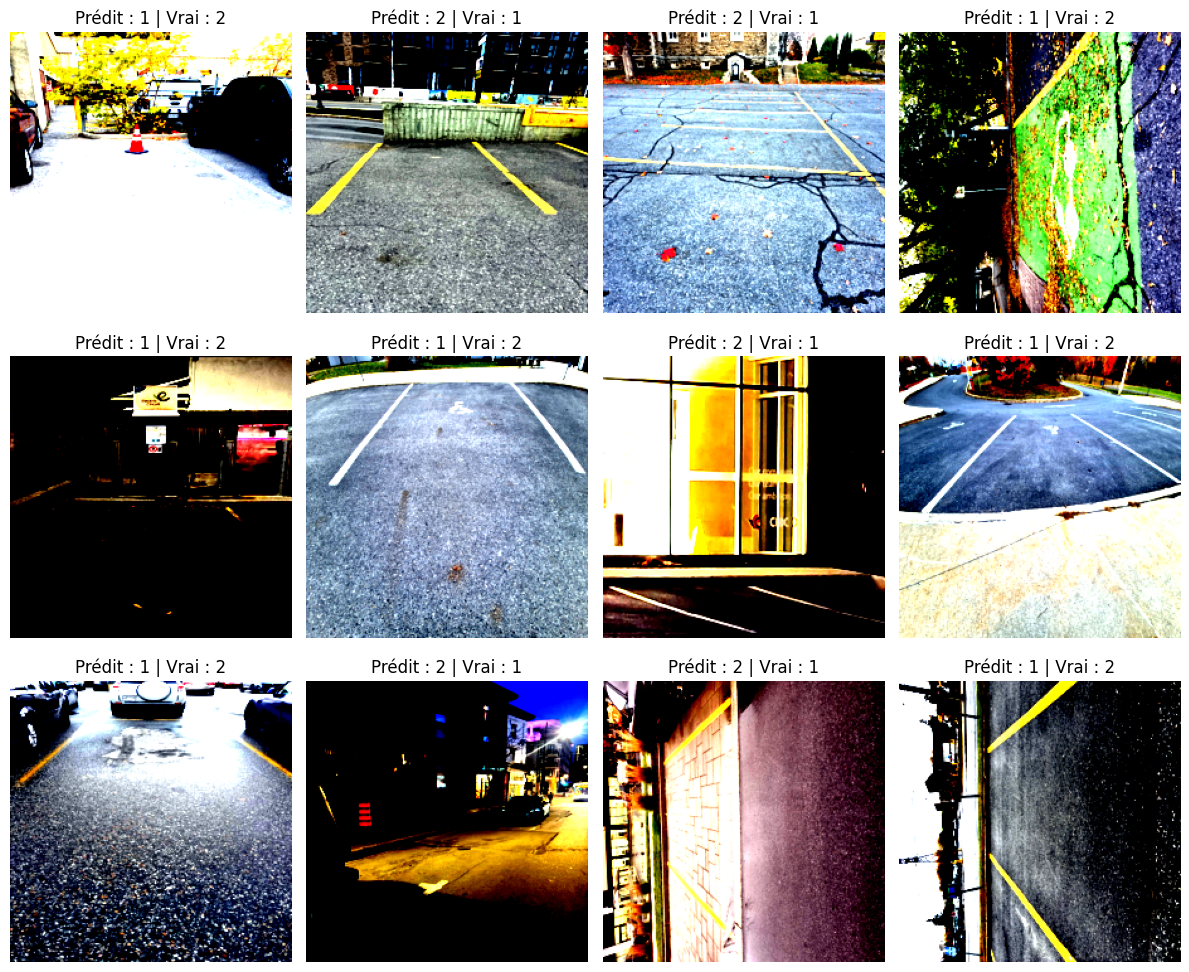

In [ ]:
import matplotlib.pyplot as plt

model = resnet18_ft
model.eval()

wrong_images = []
wrong_preds = []
true_labels = []

with torch.no_grad():
    for x,y in test_loader_tl:
        x = x.to(device)
        y = y.to(device)
        out = model(x)
        pred = out.argmax(1)

        for img, p, t in zip(x, pred, y):
            if p != t:
                wrong_images.append(img.cpu())
                wrong_preds.append(p.item())
                true_labels.append(t.item())

# Afficher les 12 premières erreurs
plt.figure(figsize=(12,10))
for i in range(min(12, len(wrong_images))):
    plt.subplot(3,4,i+1)
    plt.imshow(wrong_images[i].permute(1,2,0))
    plt.title(f"Prédit : {wrong_preds[i]} | Vrai : {true_labels[i]}")
    plt.axis("off")
plt.tight_layout()
plt.show()
